In [1]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2


def upscale_image(model, model_path, image_path, output_path, device):
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    to_tensor = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])

    lr = to_tensor(image).unsqueeze(0).to(device)

    # ---------------------------------------------------------
    # 8-way geometric ensemble
    #
    # 0: original
    # 1: rotate 90
    # 2: rotate 180
    # 3: rotate 270
    # 4: horizontal flip
    # 5: horizontal flip + rotate 90
    # 6: horizontal flip + rotate 180
    # 7: horizontal flip + rotate 270
    # ---------------------------------------------------------

    def geometric_transforms(x):
        versions = []

        # Original + rotations
        versions.append(x)
        versions.append(torch.rot90(x, k=1, dims=(-2, -1)))
        versions.append(torch.rot90(x, k=2, dims=(-2, -1)))
        versions.append(torch.rot90(x, k=3, dims=(-2, -1)))

        # Horizontal flip + rotations
        flipped = torch.flip(x, dims=(-1,))
        versions.append(flipped)
        versions.append(torch.rot90(flipped, k=1, dims=(-2, -1)))
        versions.append(torch.rot90(flipped, k=2, dims=(-2, -1)))
        versions.append(torch.rot90(flipped, k=3, dims=(-2, -1)))

        return versions

    def inverse_geometric_transform(x, index):
        """
        Undo the corresponding geometric transformation.

        x shape: [B, C, H, W]
        """

        if index == 0:
            # Original
            return x

        elif index == 1:
            # Inverse of rotate 90 = rotate 270
            return torch.rot90(x, k=3, dims=(-2, -1))

        elif index == 2:
            # Inverse of rotate 180 = rotate 180
            return torch.rot90(x, k=2, dims=(-2, -1))

        elif index == 3:
            # Inverse of rotate 270 = rotate 90
            return torch.rot90(x, k=1, dims=(-2, -1))

        elif index == 4:
            # Inverse of horizontal flip = horizontal flip
            return torch.flip(x, dims=(-1,))

        elif index == 5:
            # Forward: flip -> rotate 90
            # Inverse: rotate 270 -> flip
            x = torch.rot90(x, k=3, dims=(-2, -1))
            return torch.flip(x, dims=(-1,))

        elif index == 6:
            # Forward: flip -> rotate 180
            # Inverse: rotate 180 -> flip
            x = torch.rot90(x, k=2, dims=(-2, -1))
            return torch.flip(x, dims=(-1,))

        elif index == 7:
            # Forward: flip -> rotate 270
            # Inverse: rotate 90 -> flip
            x = torch.rot90(x, k=1, dims=(-2, -1))
            return torch.flip(x, dims=(-1,))

        else:
            raise ValueError(f"Invalid transform index: {index}")

    transforms = geometric_transforms(lr)

    predictions = []

    with torch.inference_mode():
        for i, transformed_lr in enumerate(transforms):

            with torch.autocast(
                device_type=device.type,
                dtype=torch.bfloat16
            ):
                pred = model(transformed_lr)

            # Convert prediction back to original orientation
            pred = inverse_geometric_transform(pred, i)

            predictions.append(pred.float())

    # ---------------------------------------------------------
    # Average the 8 predictions
    # ---------------------------------------------------------

    sr = torch.stack(predictions, dim=0).mean(dim=0)

    sr = sr.clamp(0, 1)

    # Convert SR tensor to NumPy for matplotlib
    sr_np = (
        sr.squeeze(0)
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    lr_np = (
        lr.squeeze(0)
        .cpu()
        .permute(1, 2, 0)
        .numpy()
    )

    # ---------------------------------------------------------
    # Save SR image
    # ---------------------------------------------------------

    sr_uint8 = (sr_np * 255).round().astype("uint8")
    Image.fromarray(sr_uint8).save(output_path)

    # ---------------------------------------------------------
    # Display
    # ---------------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(lr_np)
    axes[0].set_title(
        f"LR Input ({image.width}×{image.height})"
    )
    axes[0].axis("off")

    axes[1].imshow(sr_np)
    axes[1].set_title(
        f"SR Output ({sr_np.shape[1]}×{sr_np.shape[0]})"
    )
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Saved: {output_path}")
    print("8-way geometric ensemble applied.")

In [2]:
from models.fsrcnn import FSRCNN
from models.edsr import EDSR
from models.faster_edsr import FasterEDSR
from models.faster_rcan import FasterRCAN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

16510819


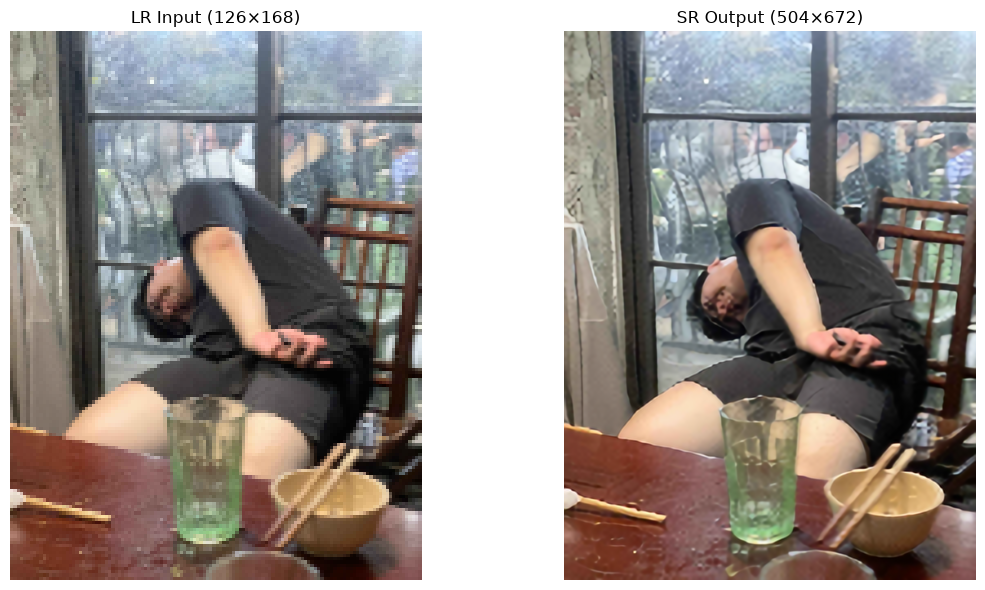

Saved: test/test_sr.png
8-way geometric ensemble applied.


In [4]:
model = FasterRCAN()
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

upscale_image(
    model=model,
    model_path="weights/faster_rcan_04.pth",
    image_path="test/thanhbeo_edited.png",
    output_path="test/test_sr.png",
    device=device
)

1832899


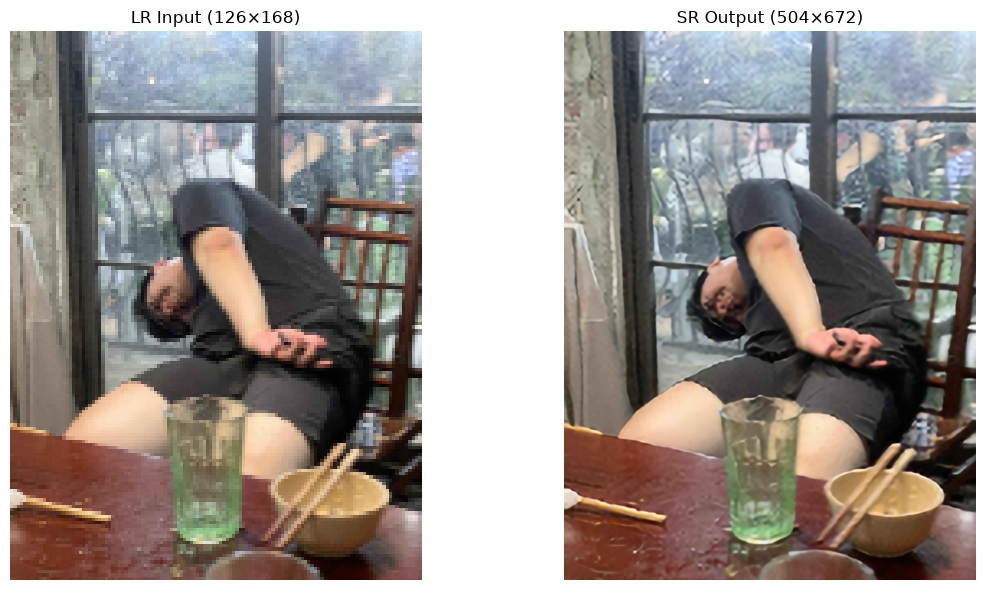

Saved: test/test_sr1.png
8-way geometric ensemble applied.


In [5]:
model = FasterEDSR()
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

upscale_image(
    model=model,
    model_path="weights/faster_edsr_06.pth",
    image_path="test/thanhbeo_edited.png",
    output_path="test/test_sr1.png",
    device=device
)